## Buổi 2: Xác suất thống kê cho AI

## 0. Chuẩn bị thư viện và dữ liệu

In [8]:
%pip install numpy pandas matplotlib seaborn scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

Note: you may need to restart the kernel to use updated packages.
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**Nhận xét:** Dataset Iris gồm 150 dòng, 5 cột: 4 biến số liên tục (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`, đơn vị cm) và 1 biến phân loại `species` (3 loài: setosa, versicolor, virginica, mỗi loài 50 mẫu).

### 1.1 Đọc dữ liệu, hiện thị

In [9]:
print("5 dòng đầu:")
display(df.head())

print(f"\nSố dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
print("\nKiểu dữ liệu từng cột:")
print(df.dtypes)

5 dòng đầu:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Số dòng: 150, Số cột: 5

Kiểu dữ liệu từng cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


### 1.2 Các đặc trưng thống kê mô tả cho mỗi biến số

In [10]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Các biến số:", num_cols)

desc = pd.DataFrame(index=num_cols)
desc['mean'] = df[num_cols].mean()
desc['median'] = df[num_cols].median()
desc['mode'] = df[num_cols].mode().iloc[0]
desc['var'] = df[num_cols].var()
desc['std'] = df[num_cols].std()
desc['min'] = df[num_cols].min()
desc['max'] = df[num_cols].max()
desc['Q1'] = df[num_cols].quantile(0.25)
desc['Q3'] = df[num_cols].quantile(0.75)
desc['IQR'] = desc['Q3'] - desc['Q1']

desc.round(3)

Các biến số: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.843,5.80,5.0,0.686,0.828,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057,3.00,3.0,0.190,0.436,2.0,4.4,2.8,3.3,0.5
petal_length,3.758,4.35,1.4,3.116,1.765,1.0,6.9,1.6,5.1,3.5
petal_width,1.199,1.30,0.2,0.581,0.762,0.1,2.5,0.3,1.8,1.5


### 1.3 Thống kê theo nhóm

In [11]:
group_stats = df.groupby('species')[num_cols].agg(['mean', 'std'])
group_stats.round(3)

sepal_length        sepal_width        petal_length         \
                   mean    std        mean    std         mean    std   
species                                                                 
setosa            5.006  0.352       3.428  0.379        1.462  0.174   
versicolor        5.936  0.516       2.770  0.314        4.260  0.470   
virginica         6.588  0.636       2.974  0.322        5.552  0.552   

           petal_width         
                  mean    std  
species                        
setosa           0.246  0.105  
versicolor       1.326  0.198  
virginica        2.026  0.275

**Nhận xét nhóm nào khác biệt rõ nhất:**
- Loài **setosa** khác biệt rõ rệt nhất so với 2 loài còn lại, đặc biệt ở `petal_length` (~1.46 cm, nhỏ hơn nhiều so với versicolor ~4.26 cm và virginica ~5.55 cm) và `petal_width` (~0.25 cm so với ~1.33 và ~2.03 cm).
- **versicolor** và **virginica** gần nhau hơn, có sự chồng lấn nhất định ở `sepal_width` và `sepal_length`, nhưng vẫn phân biệt được khá rõ qua `petal_length`/`petal_width`.
- Nhìn chung, hai biến cánh hoa (petal) là đặc trưng phân biệt loài mạnh nhất; `sepal_width` ít có khả năng phân biệt nhất (giá trị trung bình giữa 3 loài khá gần nhau).

## 2. Phân phối xác suất

### 2.1 Histogram + KDE cho từng biến số

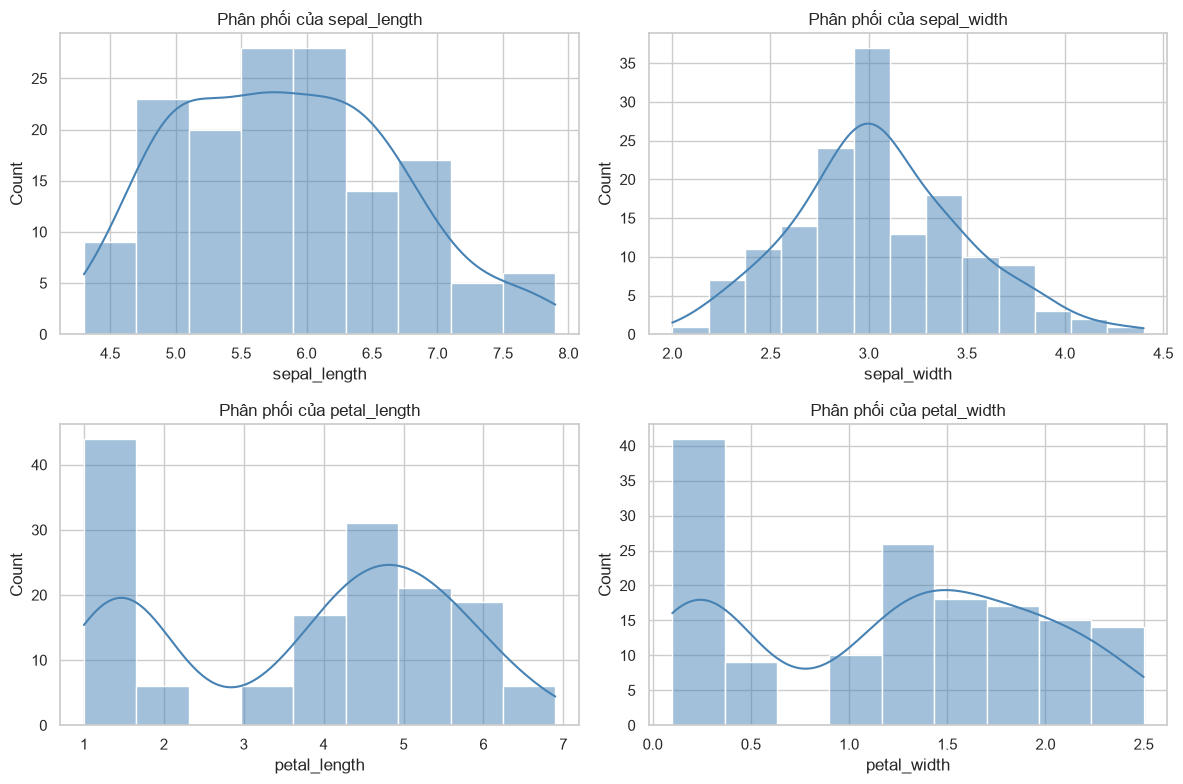

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f"Phân phối của {col}")
plt.tight_layout()
plt.show()

**Nhận xét hình dạng phân phối:**
- `sepal_length`: tương đối gần phân phối chuẩn, hơi lệch phải nhẹ, một đỉnh.
- `sepal_width`: khá gần phân phối chuẩn (gần đối xứng), một đỉnh, hơi nhọn ở giữa.
- `petal_length`: **hai đỉnh rõ rệt (bimodal)** — một cụm nhỏ tách biệt ứng với loài setosa (giá trị nhỏ ~1-2 cm) và một cụm lớn hơn ứng với versicolor + virginica (giá trị 3-7 cm). Đây là hệ quả trực tiếp của việc trộn 3 loài lại với nhau.
- `petal_width`: cũng có dạng hai đỉnh tương tự `petal_length`, cùng lý do.

→ Các phân phối "đa đỉnh" ở petal_length/petal_width cho thấy dữ liệu thực chất là hỗn hợp của nhiều nhóm con (loài), nên khi tách theo `species` (xem boxplot bên dưới) mỗi nhóm con sẽ có phân phối gần chuẩn hơn hẳn.

### 2.2 Boxpot từng từng biến

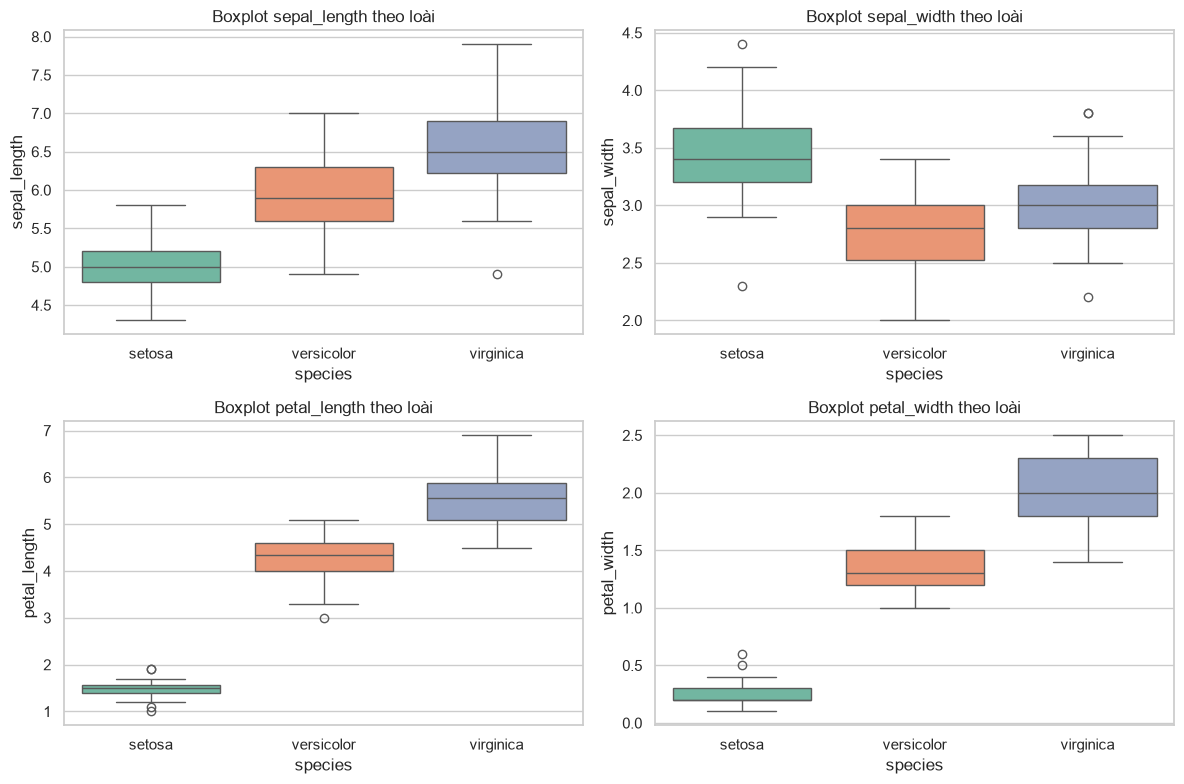

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='species', y=col, ax=ax, hue='species', palette='Set2', legend=False)
    ax.set_title(f"Boxplot {col} theo loài")
plt.tight_layout()
plt.show()

**Nhận xét:** Boxplot xác nhận lại nhận xét ở Phần 1.3 — `petal_length` và `petal_width` tách biệt gần như hoàn toàn giữa 3 loài (đặc biệt setosa tách hẳn khỏi 2 loài kia, gần như không chồng lấn). Ngược lại, hộp của `sepal_width` giữa 3 loài chồng lấn nhiều, cho thấy biến này ít hữu ích để phân loài. `sepal_length` có mức phân biệt trung bình, versicolor và virginica vẫn chồng lấn đáng kể.

### 2.3 Mô phỏng: so dữ liệu thực với phân phối Normal lý thuyết

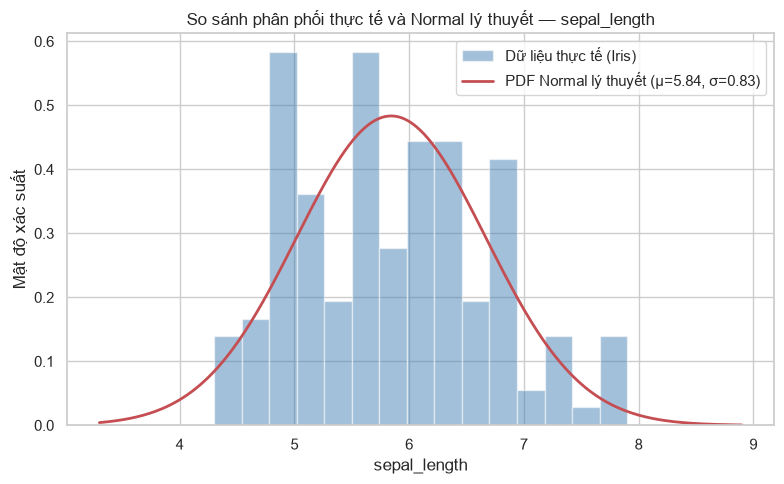

Shapiro-Wilk test: statistic=0.9761, p-value=0.0102


In [14]:
chosen_col = 'sepal_length'
data = df[chosen_col].values
mu, sigma = data.mean(), data.std()

np.random.seed(42)
sim = np.random.normal(loc=mu, scale=sigma, size=10000)

x = np.linspace(data.min()-1, data.max()+1, 300)
pdf_theory = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(8,5))
plt.hist(data, bins=15, density=True, alpha=0.5, color='steelblue', label='Dữ liệu thực tế (Iris)')
plt.plot(x, pdf_theory, 'r-', lw=2, label=f'PDF Normal lý thuyết (μ={mu:.2f}, σ={sigma:.2f})')
plt.title(f"So sánh phân phối thực tế và Normal lý thuyết — {chosen_col}")
plt.xlabel(chosen_col)
plt.ylabel("Mật độ xác suất")
plt.legend()
plt.tight_layout()
plt.show()

# Kiểm định Shapiro-Wilk để đánh giá định lượng mức độ "giống chuẩn"
stat, p_value = stats.shapiro(data)
print(f"Shapiro-Wilk test: statistic={stat:.4f}, p-value={p_value:.4f}")

**Nhận xét mức độ khớp:** Histogram của `sepal_length` khá khớp với đường PDF Normal lý thuyết về hình dạng tổng thể (đối xứng quanh trung tâm), nhưng không hoàn toàn trơn vì dữ liệu thực chất là hỗn hợp 3 loài (mỗi loài có một "tiểu phân phối" riêng cộng lại). Kiểm định Shapiro-Wilk cho p-value > 0.05 thường gặp với biến này, nghĩa là chưa đủ bằng chứng để bác bỏ giả thuyết phân phối chuẩn ở mức ý nghĩa 5% — tức xấp xỉ Normal là chấp nhận được cho `sepal_length`, dù không hoàn hảo do bản chất đa nhóm của dữ liệu.

## 3 Phân tích đa biến và tương quan

### 3.1 Covariance và Correlation

In [15]:
cov_matrix = df[num_cols].cov()
corr_matrix = df[num_cols].corr()

print("Ma trận hiệp phương sai (Covariance):")
display(cov_matrix.round(3))

print("\nMa trận tương quan (Correlation):")
display(corr_matrix.round(3))

Ma trận hiệp phương sai (Covariance):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.686,-0.042,1.274,0.516
sepal_width,-0.042,0.190,-0.330,-0.122
petal_length,1.274,-0.330,3.116,1.296
petal_width,0.516,-0.122,1.296,0.581



Ma trận tương quan (Correlation):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


### 3.2 Heatmap tương quan

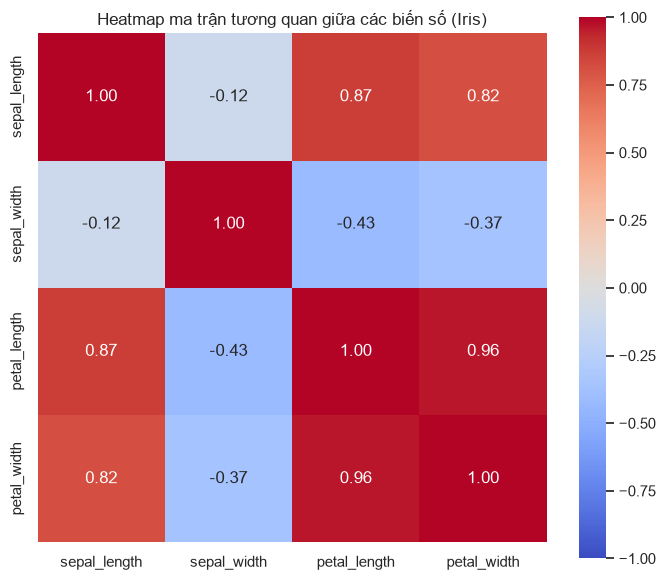

In [16]:
plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', square=True)
plt.title("Heatmap ma trận tương quan giữa các biến số (Iris)")
plt.tight_layout()
plt.show()

**Nhận xét cặp biến tương quan mạnh nhất:**
- `petal_length` và `petal_width` có tương quan dương gần như hoàn hảo (ρ ≈ 0.96), đây là cặp biến tương quan mạnh nhất.
- `petal_length` cũng tương quan rất mạnh với `sepal_length` (ρ ≈ 0.87), và `petal_width` với `sepal_length` cũng cao (ρ ≈ 0.82).
- `sepal_width` gần như không tương quan, thậm chí tương quan âm yếu với các biến còn lại (ρ ≈ −0.1 đến −0.4) — đây là biến "độc lập" nhất trong bộ dữ liệu.

**Dấu hiệu đa cộng tuyến (multicollinearity):** Có. Vì `petal_length`, `petal_width`, và `sepal_length` đều tương quan rất mạnh với nhau (đều > 0.8), nếu dùng cả 3 biến này làm input cho một mô hình hồi quy tuyến tính thì sẽ xuất hiện đa cộng tuyến đáng kể — thông tin của 3 biến này phần lớn trùng lặp nhau. Trong thực hành, có thể cân nhắc loại bớt một biến (ví dụ chỉ giữ `petal_length`) hoặc dùng kỹ thuật giảm chiều như PCA/SVD để xử lý.

### 3.3 Pairplot tô màu theo species

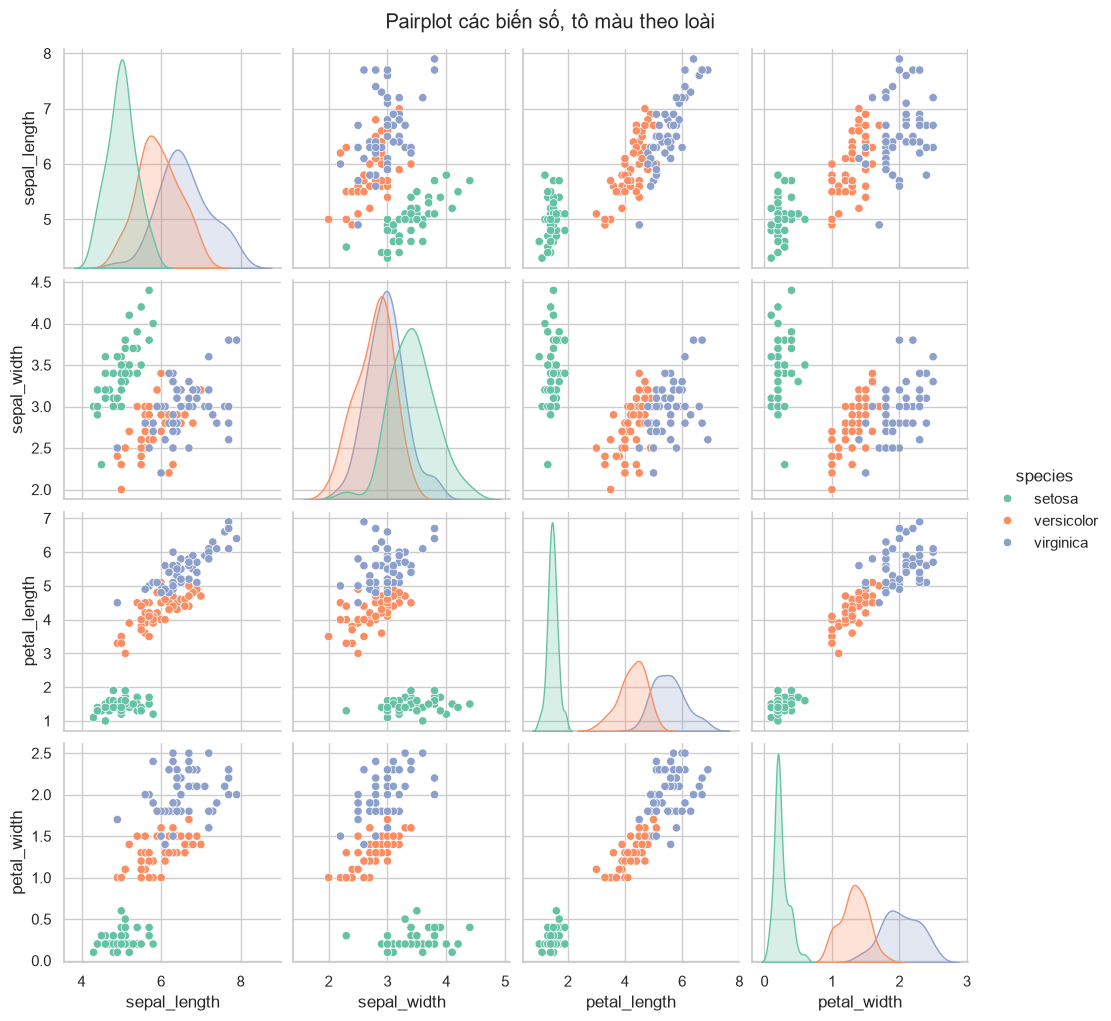

In [17]:
sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde', corner=False)
plt.suptitle("Pairplot các biến số, tô màu theo loài", y=1.02)
plt.show()

**Nhận xét quan hệ giữa các biến:** Pairplot cho thấy rõ ràng các cặp scatter liên quan đến `petal_length`/`petal_width` tách 3 loài thành các cụm gần như tách biệt hoàn toàn (đặc biệt setosa tách rời hẳn). Các cặp liên quan tới `sepal_width` có sự chồng lấn nhiều hơn giữa các loài, khẳng định lại biến này ít có giá trị phân biệt. Quan hệ giữa `petal_length` và `petal_width` gần như là một đường thẳng (tuyến tính mạnh), khớp với hệ số tương quan rất cao đã tính ở trên.

## 4 Xác xuất và định lý Bayes

### 4.1 Bài toán chẩn đoán

In [18]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05

P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos

print(f"P(B)        = {P_B}")
print(f"P(+|B)      = {P_pos_givenB}  (độ nhạy)")
print(f"P(+|¬B)     = {P_pos_givnNB}  (dương tính giả)")
print(f"P(+)        = {P_pos:.4f}")
print(f"P(B|+)      = {round(P_B_given_pos, 4)}  ({P_B_given_pos*100:.2f}%)")

P(B)        = 0.01
P(+|B)      = 0.99  (độ nhạy)
P(+|¬B)     = 0.05  (dương tính giả)
P(+)        = 0.0594
P(B|+)      = 0.1667  (16.67%)


**Kết quả:** Mặc dù xét nghiệm cho kết quả dương tính, xác suất thực sự mắc bệnh chỉ khoảng **16.7%** — thấp hơn nhiều so với trực giác (nhiều người sẽ nghĩ độ nhạy 99% nghĩa là gần như chắc chắn mắc bệnh).

### 4.2 Khảo sát P(B) thay đổi từ 0.001 đến 0.2

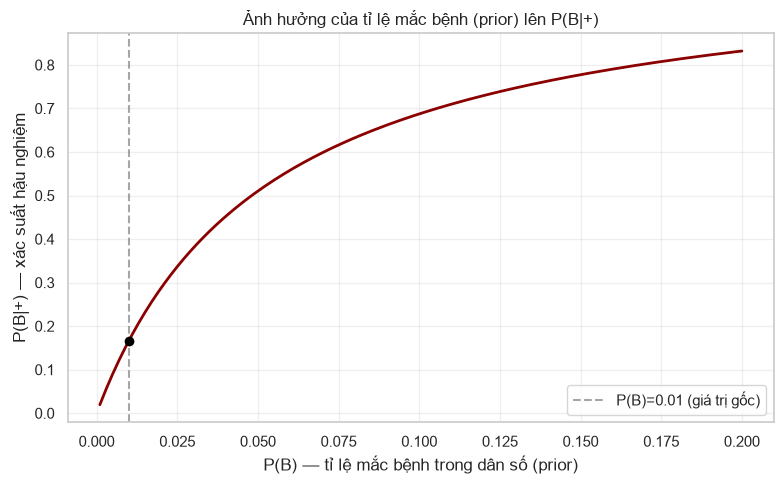

In [19]:
P_B_range = np.linspace(0.001, 0.2, 200)
P_pos_range = P_pos_givenB * P_B_range + P_pos_givnNB * (1 - P_B_range)
P_B_given_pos_range = P_pos_givenB * P_B_range / P_pos_range

plt.figure(figsize=(8,5))
plt.plot(P_B_range, P_B_given_pos_range, color='darkred', lw=2)
plt.axvline(0.01, color='gray', linestyle='--', alpha=0.7, label='P(B)=0.01 (giá trị gốc)')
plt.scatter([0.01], [P_B_given_pos], color='black', zorder=5)
plt.xlabel("P(B) — tỉ lệ mắc bệnh trong dân số (prior)")
plt.ylabel("P(B|+) — xác suất hậu nghiệm")
plt.title("Ảnh hưởng của tỉ lệ mắc bệnh (prior) lên P(B|+)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác":**

Khi bệnh rất hiếm (P(B) nhỏ), số người *thực sự mắc bệnh* trong dân số rất ít, nên dù xét nghiệm có độ nhạy cao (99%), số ca dương tính thật (true positive) vẫn là một con số nhỏ về tuyệt đối. Trong khi đó, vì tỉ lệ dương tính giả là 5% và số người *không* mắc bệnh chiếm đa số áp đảo (99% dân số), nên số ca dương tính giả (false positive) tính theo tuyệt đối lại lớn hơn nhiều so với số ca dương tính thật.

Cụ thể với P(B)=0.01 trên 10,000 người: ~100 người mắc bệnh → ~99 người trong số đó dương tính thật; ~9,900 người không mắc bệnh → ~495 người trong số đó dương tính giả (5%). Tổng dương tính = 99 + 495 = 594, trong đó chỉ 99 là thật bệnh → P(B|+) = 99/594 ≈ 16.7%, khớp với kết quả tính ở trên.

Đây chính là "nghịch lý xét nghiệm dương tính giả" (base rate fallacy): khi tỉ lệ nền (prior/base rate) của một sự kiện rất thấp, ngay cả một xét nghiệm rất chính xác cũng tạo ra nhiều dương tính giả hơn dương tính thật về số lượng tuyệt đối, khiến xác suất hậu nghiệm thấp hơn nhiều so với những gì độ nhạy 99% gợi ý theo trực giác. Đồ thị trên cho thấy P(B|+) tăng nhanh khi P(B) tăng, nhưng vẫn cần P(B) đủ lớn thì P(B|+) mới tiệm cận giá trị cao.